In [1]:
from utils import calc_r_squared, build_expression
from ponto2D import ListaPontos2D
from minimos_quadrados import get_coeficientes
from non_linear import growth_regression, exponencial_regression, potencia_regression
import matplotlib.pyplot as plt
import numpy as np

In [2]:
x_values = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
y_values = [17, 24, 31, 33, 37, 37, 40, 40, 42, 41]
pontos = ListaPontos2D.from_x_y_values(x_values, y_values)
pontos.print()

(5, 17)
(10, 24)
(15, 31)
(20, 33)
(25, 37)
(30, 37)
(35, 40)
(40, 40)
(45, 42)
(50, 41)


In [3]:
ajustes = {
    'Reta': {'coeficientes': get_coeficientes(pontos, grau=1)},
    'Potencia': {'coeficientes': potencia_regression(pontos)},
    'Exponencial': {'coeficientes': exponencial_regression(pontos)},
    'Saturacao': {'coeficientes': growth_regression(pontos)},
    'Parabola': {'coeficientes': get_coeficientes(pontos, grau=2)},
}

for key, value in ajustes.items():
    ajustes[key]['expressao'] = build_expression(key.lower(), value['coeficientes'])

In [4]:
def plot_ajustes(x_values, y_values, ajustes):
    plt.figure(figsize=(10, 6))
    plt.scatter(x_values, y_values, color='red', label='Dados Originais')

    x_range = np.linspace(min(x_values), max(x_values), 1000)

    for ajuste, info in ajustes.items():
        expressao = info['expressao']
        y_fit = [expressao.subs({'x': x}) for x in x_range]
        r_squared = calc_r_squared(pontos, info['expressao'])
        plt.plot(x_range, y_fit, label=f'{ajuste} (R²={r_squared:.4f})')

    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Ajustes de Curvas')
    plt.legend()
    plt.show()

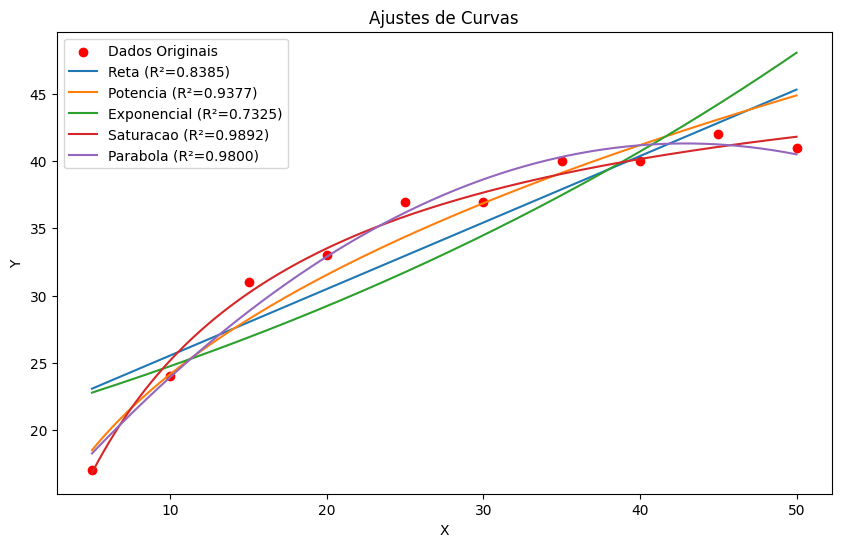

In [5]:
plot_ajustes(x_values, y_values, ajustes)

In [6]:
for ajuste, coeficientes in ajustes.items():
    print(f"{ajuste} coeficientes: {coeficientes['coeficientes']}")
    print(f"{ajuste} expressão: {coeficientes['expressao']}")
    r_squared = calc_r_squared(pontos, coeficientes['expressao'])
    print(f"{ajuste} R²: {r_squared}\n")

Reta coeficientes: [20.6, 0.49454545454545457]
Reta expressão: 0.494545454545455*x + 20.6
Reta R²: 0.8384912959381046

Potencia coeficientes: [9.95291511128898, 0.38507720531853434]
Potencia expressão: 9.95291511128898*x**0.385077205318534
Potencia R²: 0.9377000865888194

Exponencial coeficientes: [20.96503334306343, 0.01659650417632365]
Exponencial expressão: 20.9650333430634*exp(0.0165965041763237*x)
Exponencial R²: 0.7324670731368819

Saturacao coeficientes: [50.092118192132745, 9.891368679532242]
Saturacao expressão: 50.0921181921327*x/(x + 9.89136867953224)
Saturacao R²: 0.9891903552204967

Parabola coeficientes: [11.766666666666723, 1.377878787878782, -0.016060606060605952]
Parabola expressão: -0.016060606060606*x**2 + 1.37787878787878*x + 11.7666666666667
Parabola R²: 0.9799826724693744



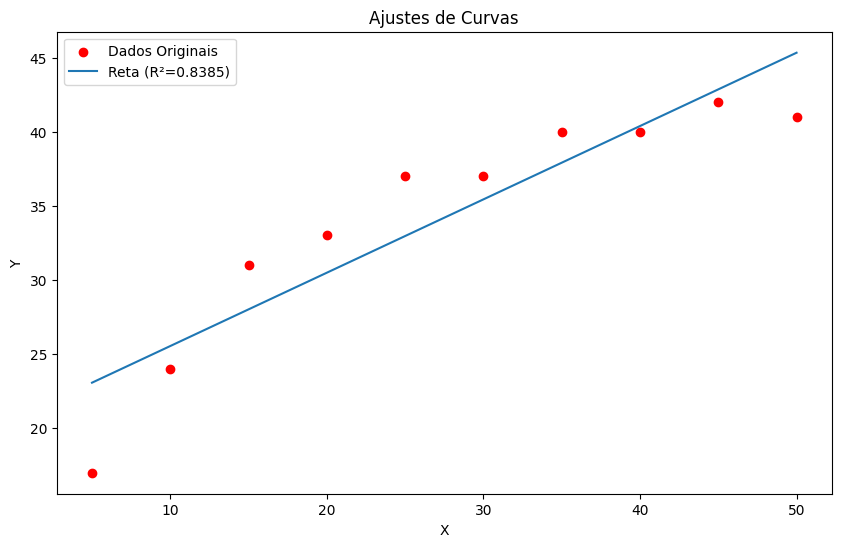

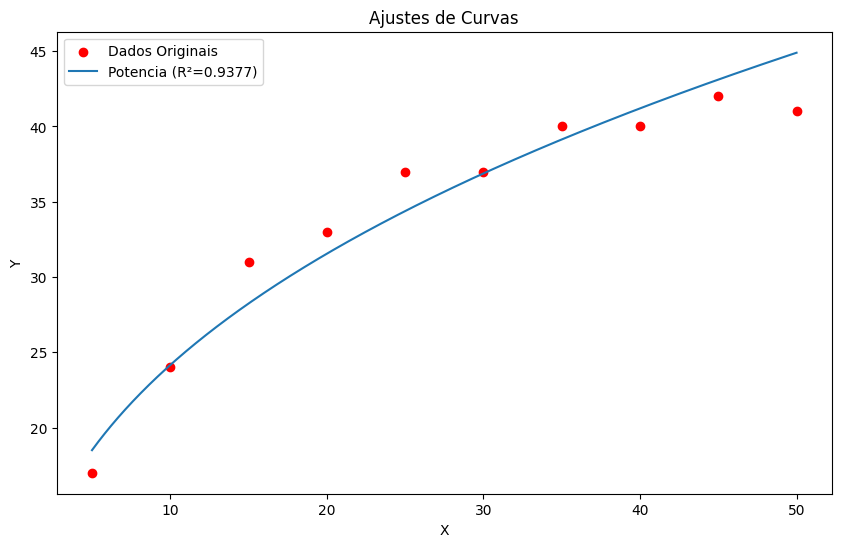

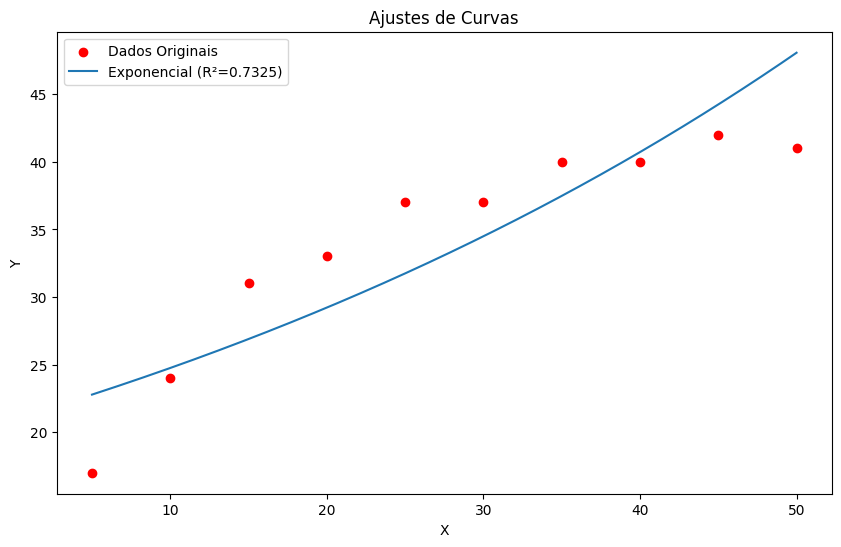

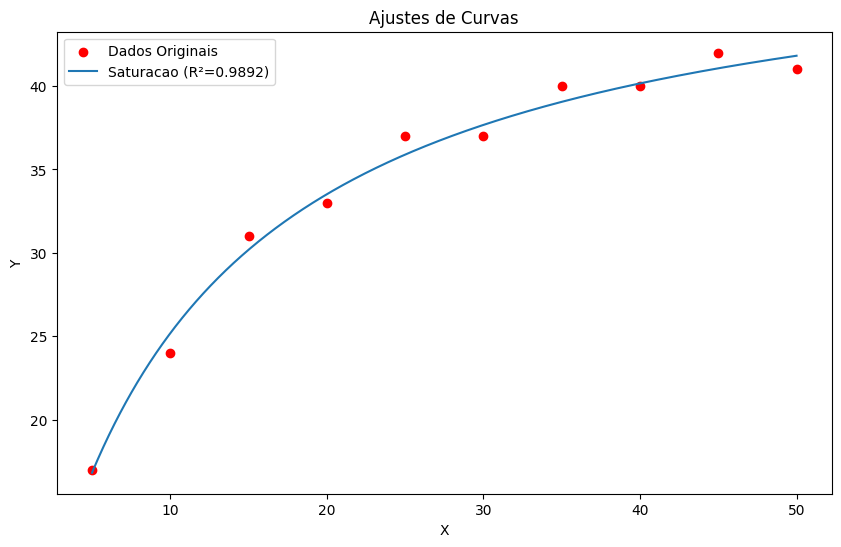

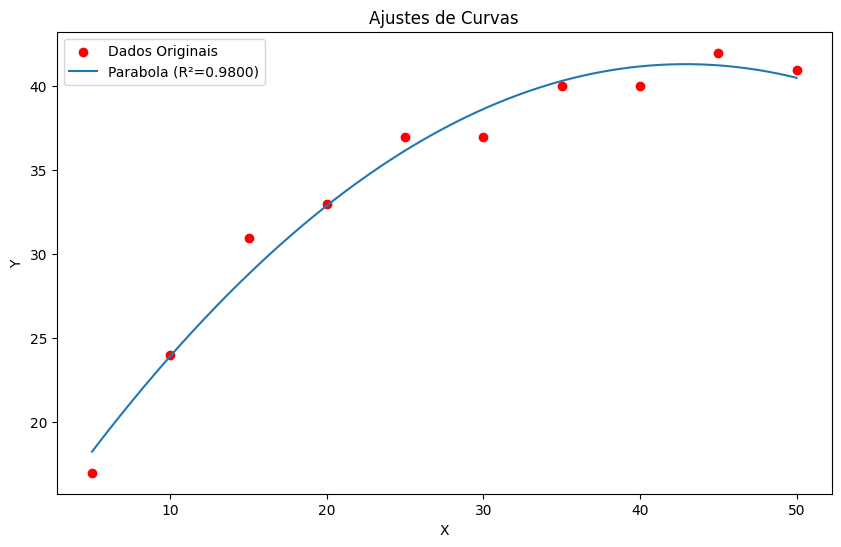

In [7]:
for ajuste, coeficientes in ajustes.items():
    plot_ajustes(x_values, y_values, {ajuste: coeficientes})

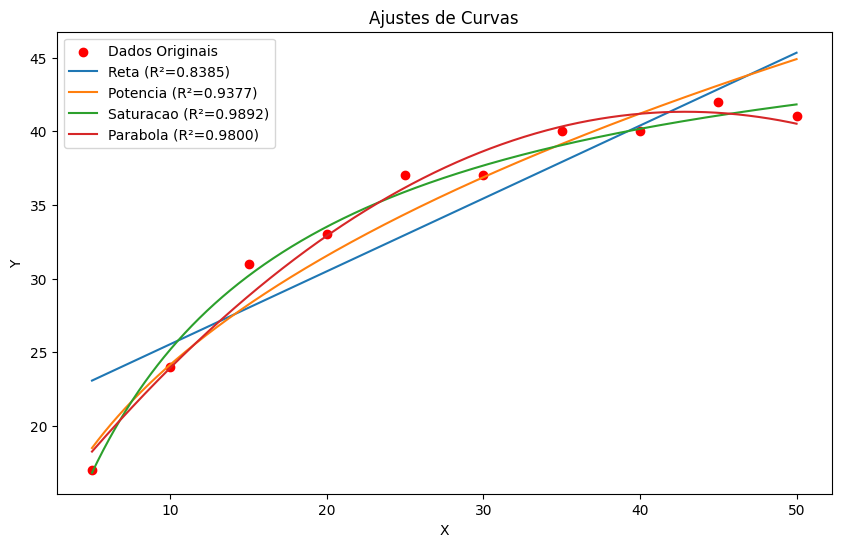

In [8]:
ajustes.pop('Exponencial')
plot_ajustes(x_values, y_values, ajustes)